In [ ]:
%pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 12.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image

# Initialize Mediapipe Hands
mp_hands = mp.solutions.hands

def scale_polygon(points, scale=100.0):
    """
    Scale polygon (list of [x,y]) outward from centroid.
    """
    points = np.array(points, dtype=np.float32)
    centroid = np.mean(points, axis=0)
    scaled = (points - centroid) * scale + centroid
    return scaled.astype(np.int32)


def extract_hand_mask(image):
    """
    Detect hand and return binary mask of hand region using convex hull of landmarks.
    """
    h, w, _ = image.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:

        # Convert to RGB for Mediapipe
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        if results.multi_hand_landmarks:
            print(len(results.multi_hand_landmarks))
            for hand_landmarks in results.multi_hand_landmarks:
                points = []
                for lm in hand_landmarks.landmark:
                    px, py = int(lm.x * w), int(lm.y * h)
                    # keep points inside image bounds
                    if 0 <= px < w and 0 <= py < h:
                        points.append([px, py])

                if len(points) > 2:
                    # convert to numpy in correct shape for OpenCV
                    points = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
                    hull = cv2.convexHull(points)

                    # hull is (N,1,2) -> reduce to (N,2) for scaling
                    hull_scaled = scale_polygon(hull[:, 0, :], scale=1.5)

                    # fill back into mask
                    cv2.fillConvexPoly(mask, hull_scaled, 255)

    return mask



def restore_hand(original_img, tryon_img):
    # resize original to match tryon
    h_tryon, w_tryon, _ = tryon_img.shape
    original_resized = cv2.resize(original_img, (w_tryon, h_tryon))

    """Blend original hand into try-on image safely."""
    hand_mask = extract_hand_mask(original_resized)

    # Ensure mask has 3 channels
    mask_3c = cv2.merge([hand_mask, hand_mask, hand_mask])

    # Compute center inside tryon bounds
    M = cv2.moments(hand_mask)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        print("No hand detected!")
        return tryon_img
    center = (cx, cy)

    # return hand_mask, center

    # Hand region
    hand_region = cv2.bitwise_and(original_resized, mask_3c)
    gray_hand = cv2.cvtColor(hand_region, cv2.COLOR_BGR2GRAY)
    _, hand_mask = cv2.threshold(gray_hand, 70, 255, cv2.THRESH_BINARY)

    mask_3c = cv2.merge([hand_mask, hand_mask, hand_mask])

    blended = np.where(mask_3c == 255, original_resized, tryon_img)

    # Get dimensions of tryon image
    h_tryon, w_tryon, _ = tryon_img.shape

    blended = np.zeros_like(tryon_img)
    for i in range(h_tryon):
        for j in range(w_tryon):
            if hand_mask[i][j] == 0:
                blended[i][j] = tryon_img[i][j]
            else:
                blended[i][j] = original_resized[i][j]

    # Ensure center is within tryon image bounds
    # cx = max(0, min(cx, w_tryon - 1))
    # cy = max(0, min(cy, h_tryon - 1))
    # center = (cx, cy)

    # # Apply seamlessClone safely
    # blended = cv2.seamlessClone(hand_region, tryon_img, hand_mask, center, cv2.NORMAL_CLONE)
    return blended


if __name__ == "__main__":
    original = cv2.imread("/content/3.png")   # original
    tryon = cv2.imread("/content/3res.png")   # try-on


    restored = restore_hand(original, tryon)
    # print(restored)
    # restored.show()

    # cv2.imwrite("/content/restored.png", restored)
    cv2_imshow(restored)

ModuleNotFoundError: No module named 'mediapipe'

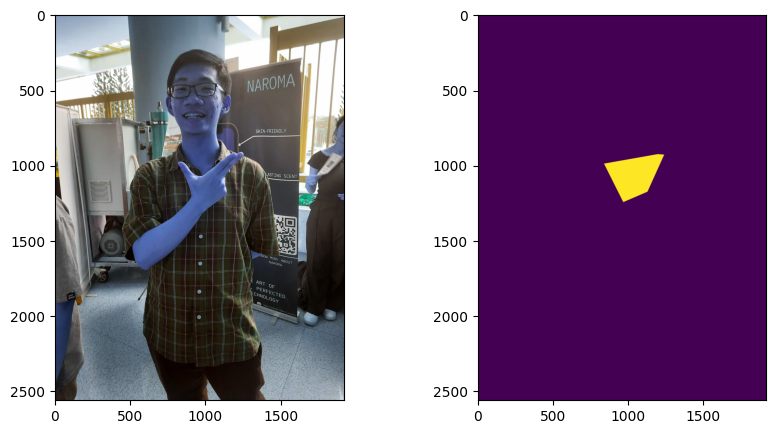

In [ ]:
import matplotlib.pyplot as plt

# plot two images nearby
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.subplot(1, 2, 2)
plt.imshow(restored[0])

plt.show()

# Inpainting

1


Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionInpaintPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

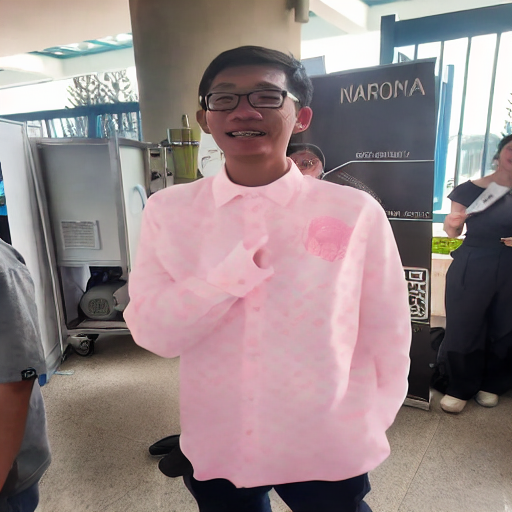

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
from google.colab.patches import cv2_imshow
from diffusers import StableDiffusionInpaintPipeline
import torch
from PIL import Image

# Initialize Mediapipe Hands
mp_hands = mp.solutions.hands

def scale_polygon(points, scale=100.0):
    """
    Scale polygon (list of [x,y]) outward from centroid.
    """
    points = np.array(points, dtype=np.float32)
    centroid = np.mean(points, axis=0)
    scaled = (points - centroid) * scale + centroid
    return scaled.astype(np.int32)


def extract_hand_mask(image):
    """
    Detect hand and return binary mask of hand region using convex hull of landmarks.
    """
    h, w, _ = image.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:

        # Convert to RGB for Mediapipe
        results = hands.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        if results.multi_hand_landmarks:
            print(len(results.multi_hand_landmarks))
            for hand_landmarks in results.multi_hand_landmarks:
                points = []
                for lm in hand_landmarks.landmark:
                    px, py = int(lm.x * w), int(lm.y * h)
                    # keep points inside image bounds
                    if 0 <= px < w and 0 <= py < h:
                        points.append([px, py])

                if len(points) > 2:
                    # convert to numpy in correct shape for OpenCV
                    points = np.array(points, dtype=np.int32).reshape(-1, 1, 2)
                    hull = cv2.convexHull(points)

                    # hull is (N,1,2) -> reduce to (N,2) for scaling
                    hull_scaled = scale_polygon(hull[:, 0, :], scale=1.5)

                    # fill back into mask
                    cv2.fillConvexPoly(mask, hull_scaled, 255)

    return mask



def restore_hand(original_img, tryon_img):
    # resize original to match tryon
    h_tryon, w_tryon, _ = tryon_img.shape
    original_resized = cv2.resize(original_img, (w_tryon, h_tryon))

    """Blend original hand into try-on image safely."""
    hand_mask = extract_hand_mask(tryon_img)

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "runwayml/stable-diffusion-inpainting", dtype=torch.float16
    ).to("cuda")

    result = pipe(
        prompt="restore original hand",
        image=Image.fromarray(tryon_img),
        mask_image=Image.fromarray(hand_mask),
    ).images[0]


    return result


if __name__ == "__main__":
    original = cv2.imread("/content/1.jpg")   # original
    tryon = cv2.imread("/content/2res.png")   # try-on


    restored = restore_hand(original, tryon)
    # print(restored)
    # restored.show()

    # cv2.imwrite("/content/restored.png", restored)
    cv2_imshow(np.array(restored))

In [ ]:
%pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 130.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.0
    Uninstalling transformers-4.57.0:
      Successfully uninstalled transformers-4.57.0


# QWEN

In [ ]:
%pip install git+https://github.com/huggingface/diffusers


  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-alzlp3xk
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-alzlp3xk
  Resolved https://github.com/huggingface/diffusers to commit f072c64bf22c6a259d38435b19a8ef3eb67c96a8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.36.0.dev0-py3-none-any.whl size=4273941 sha256=39dcc49d47f4f8f57ed44c0d5781ab1d7bb3a84f6116e8dab5a7b28683340f9a
  Stored in directory: /tmp/pip-ephem-wheel-cache-kmzx_zil/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.35.1
    Uninstalling diffusers-0.35.1:
      Successfully uninstalled diffusers-0.35.1


In [ ]:
import os
import torch
from PIL import Image
from diffusers import QwenImageEditPipeline

pipeline = QwenImageEditPipeline.from_pretrained("Qwen/Qwen-Image-Edit-2509")
print("pipeline loaded")

pipeline.to('cuda')
pipeline.set_progress_bar_config(disable=True)
image1 = Image.open("/content/1.jpg")
image2 = Image.open("/content/2res.png")
prompt = "The first image is original and second image is after trying on. The hand after trying on look weird. I want you to remodified the hand like in original image"

input = {
    "image": [image1, image2],
    "prompt": prompt,
    "generator": torch.manual_seed(0),
    "true_cfg_scale": 4.0,
    "negative_prompt": "the hands look weird. Change of pose",
    "num_inference_steps": 40,
    "guidance_scale": 1.0,
    "num_images_per_prompt": 1,
}
with torch.inference_mode():
    output = pipeline(**input)
    output_image = output.images[0]
    output_image.save("output.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/516 [00:00<?, ?B/s]

Fetching 32 files:   0%|          | 0/32 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/788 [00:00<?, ?B/s]

...

transformer/diffusion_pytorch_model-0000(…):   0%|          | 0.00/982M [00:00<?, ?B/s]

(…)ion_pytorch_model.safetensors.index.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/254M [00:00<?, ?B/s]

KeyboardInterrupt: 